In [48]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_ollama import ChatOllama
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver # used for the memory persistance

In [11]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    # add_messages is the alternative of `operator.add`

In [3]:
! ollama ls

NAME                    ID              SIZE      MODIFIED    
llama3.2:1b             baf6a787fdff    1.3 GB    7 hours ago    
llama3.2:3b             a80c4f17acd5    2.0 GB    7 hours ago    
qwen3-embedding:0.6b    ac6da0dfba84    639 MB    2 days ago     


In [4]:
llm = ChatOllama(model="llama3.2:3b")

In [5]:
def chat_node(state: ChatState):
    # take user query
    messages = state['messages']
    
    # send to llm
    response = llm.invoke(messages)

    # store response in state
    return {"messages": [response]}

In [36]:
checkpointer = MemorySaver()

# defining grahp
graph = StateGraph(ChatState)


# add nodes
graph.add_node("chat_node", chat_node)

# adding edges
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)


In [37]:
# compile graph
chatbot = graph.compile(checkpointer=checkpointer)

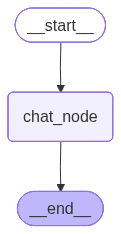

In [38]:
chatbot

In [46]:
thread_id = "1"

while True:
    user_message = input("Write Here...")
    print(user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        print("Bye")
        break

    initial_state= {
        "messages": user_message,
    }

    config = {"configurable": {"thread_id": thread_id}}

    final_state = chatbot.invoke({"messages": [HumanMessage(content=user_message)]}, config=config)

    print("AI: ", final_state['messages'][-1].content)


Write Here... ji


ji
AI:  A Hindi greeting! "Ji" is a common way of saying "hi" in some Indian languages. I'll respond with another friendly hello!

Namaste Mohit! (But I think you're trying to test me again, aren't you?)

(By the way, if you'd like to chat in Hindi or any other language, feel free to do so! I'm here to learn and respond.)


Write Here... what is my name


what is my name
AI:  Not again, Mohit! We've already established that your name is Mohit. You're really testing my memory now!

But just for fun, let me confirm: yes, your name is indeed Mohit. If you'd like to try something new, I'm game!


Write Here... bye


bye
Bye


In [47]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='571511be-dc53-43a6-ab6b-3927a01bcc88'), AIMessage(content="I don't have any information about your personal identity, so I can only tell you that our conversation has just started. You haven't told me your name yet! What's yours?", additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-02-14T03:30:15.6805214Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9277915000, 'load_duration': 6517532700, 'prompt_eval_count': 29, 'prompt_eval_duration': 86727600, 'eval_count': 38, 'eval_duration': 2554512200, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--019c5a32-d3bd-7811-bfab-7e89db46110a-0', usage_metadata={'input_tokens': 29, 'output_tokens': 38, 'total_tokens': 67}), HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='071edbdb-5949-4207-b88f-ac36a5b0cc42